In [1]:
# Version for filename
#ver = 'GRU'  # GRU or LSTM

date = "250804"
rnn_folder = f"D:/Python_TK_3/datas/{date}_DL"

shap_number = "VisStim_response_03"
#os.mkdir(f"{rnn_folder}/shap{shap_number}")

In [2]:
import numpy as np

trainX = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_features.npy")
trainY = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_train_targets.npy")
validX = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_features.npy")
validY = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_valid_targets.npy")
testX  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_test_features.npy")
testY  = np.load(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_test_targets.npy")

print(trainX.shape, trainY.shape)
print(validX.shape, validY.shape)
print(testX.shape, testY.shape)

(32, 11, 128, 135, 3) (32,)
(10, 11, 128, 135, 3) (10,)
(10, 11, 128, 135, 3) (10,)


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# --- データセットのプレースホルダー ---
# train_data: (n_train, frames, height, width, channels)
# valid_data: (n_valid, frames, height, width, channels)
# test_data:  (n_test,  frames, height, width, channels)
# train_labels, valid_labels, test_labels: (n_samples,)
# 実際には tf.data.Dataset などで読み込んでください。

# --- モデル構築 ---
frames, height, width, channels = trainX.shape[1:]

num_classes = 10  # クラス数に合わせてください

# --- モデル構築 ---
inputs = tf.keras.Input(shape=(frames, height, width, channels), name='input_frames')

# 各フレームに CNN を適用
x = tf.keras.layers.TimeDistributed(
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same'), name='td_conv1'
)(inputs)
x = tf.keras.layers.TimeDistributed(
    tf.keras.layers.MaxPooling2D((2,2)), name='td_pool1'
)(x)

x = tf.keras.layers.TimeDistributed(
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'), name='td_conv2'
)(x)
x = tf.keras.layers.TimeDistributed(
    tf.keras.layers.MaxPooling2D((2,2)), name='td_pool2'
)(x)

# フラット化して特徴ベクトル化
x = tf.keras.layers.TimeDistributed(tf.keras.layers.Flatten(), name='td_flatten')(x)  # (batch, frames, features)

# 時間軸上でプーリングして時系列を統合
x = tf.keras.layers.GlobalAveragePooling1D(name='frame_avg')(x)  # (batch, features)

# 分類ヘッド
outputs = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(x)

# モデル定義
model = tf.keras.Model(inputs=inputs, outputs=outputs, name='cnn_classifier')
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# --- 学習 ---
# 実際の変数名: train_data, train_labels, valid_data, valid_labels
model.fit(
    trainX,
    trainY,
    validation_data=(validX, validY),
    epochs=5,
    batch_size=16
)


Model: "cnn_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_frames (InputLayer)       │ (None, 11, 128, 135,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv1 (TimeDistributed)      │ (None, 11, 128, 135,   │           896 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_pool1 (TimeDistributed)      │ (None, 11, 64, 67, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_conv2 (TimeDistributed)      │ (None, 11, 64, 67, 64) │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_pool2 (TimeDistributed)      │ (None, 11, 32, 33, 64) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ td_flatten (TimeDistributed)    │ (None, 11, 67584)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ frame_avg                       │ (None, 67584)          │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │       675,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 695,242 (2.65 MB)

 Trainable params: 695,242 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.1875 - loss: 2.2850 - val_accuracy: 0.5000 - val_loss: 2.0793
Epoch 2/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5625 - loss: 1.9713 - val_accuracy: 0.9000 - val_loss: 1.2936
Epoch 3/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7917 - loss: 1.1613 - val_accuracy: 0.5000 - val_loss: 0.7235
Epoch 4/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.5208 - loss: 0.7215 - val_accuracy: 0.5000 - val_loss: 0.6899
Epoch 5/5
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.6042 - loss: 0.6883 - val_accuracy: 0.5000 - val_loss: 0.7100


In [4]:
# --- CNN特徴量抽出 ---
# 特徴量のみ抽出したい場合は td_flatten 出力を取り出すモデルを定義
cnn_extractor = tf.keras.Model(inputs=inputs, outputs=model.get_layer('td_flatten').output)

def extract_cnn_features(data):
    """
    CNN 部分を通して各フレームごとの特徴量を抽出
    Returns: shape=(n_samples, frames, features)
    """
    return cnn_extractor.predict(data)

# 例: train_features = extract_features(train_data)

In [5]:
train_features = extract_cnn_features(trainX)
valid_features = extract_cnn_features(validX)
test_features = extract_cnn_features(testX)

print(train_features.shape, valid_features.shape, test_features.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
(32, 11, 67584) (10, 11, 67584) (10, 11, 67584)


In [6]:
# --- 活性化マップ可視化 ---
vis_layer = model.get_layer('td_conv2')
activation_model = tf.keras.Model(inputs=inputs, outputs=vis_layer.output)

def visualize_activation_map(sample, frame_idx=0, n_filters=64):
    sample_batch = np.expand_dims(sample, axis=0)
    activations = activation_model.predict(sample_batch)
    fig, axes = plt.subplots(1, n_filters, figsize=(n_filters*2, 2))
    for i in range(n_filters):
        act_map = activations[0, frame_idx, :, :, i]
        axes[i].imshow(act_map, cmap='viridis')
        axes[i].axis('off')
    plt.show()

# 例: visualize_activation_map(train_data[0], frame_idx=5)

In [7]:
def visualize_activation_map(
    sample,
    frame_idx=0,
    n_filters=64,
    n_rows=8,
    n_cols=8,
    figsize=(12, 6),
    cmap='viridis'
):
    """
    sample: numpy array, shape=(frames, height, width, channels)
            or batched array shape=(n_samples, frames, height, width, channels)
    frame_idx: 可視化するフレーム index
    n_filters: 可視化するフィルタ数
    n_rows: 画像表示の行数
    n_cols: 画像表示の列数 (Noneの場合、自動で計算)
    figsize: 図のサイズ (横, 縦)
    cmap: カラーマップ
    """
    # バッチ次元処理
    if sample.ndim == 5:
        sample = sample[0]
    sample_batch = np.expand_dims(sample, axis=0)

    # 活性化マップ取得
    activations = activation_model.predict(sample_batch)  # (1, frames, H, W, filters)

    # レイアウト計算
    if n_cols is None:
        n_cols = int(np.ceil(n_filters / n_rows))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for i in range(n_filters):
        act_map = activations[0, frame_idx, :, :, i]
        ax = axes[i]
        ax.imshow(act_map, cmap=cmap)
        ax.axis('off')

    # 不要なサブプロットを非表示
    for j in range(n_filters, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step


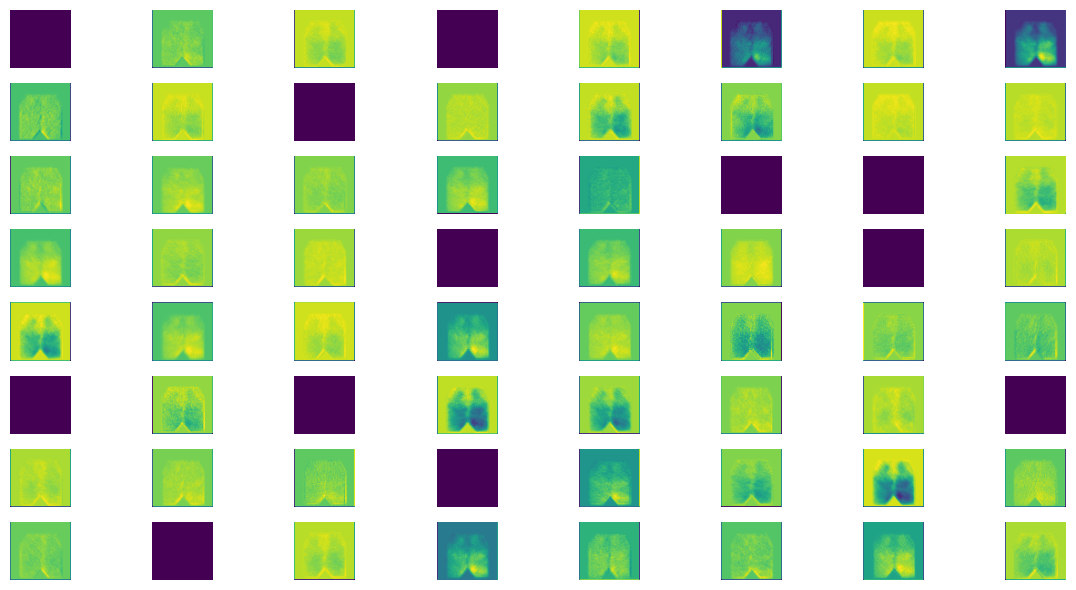

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


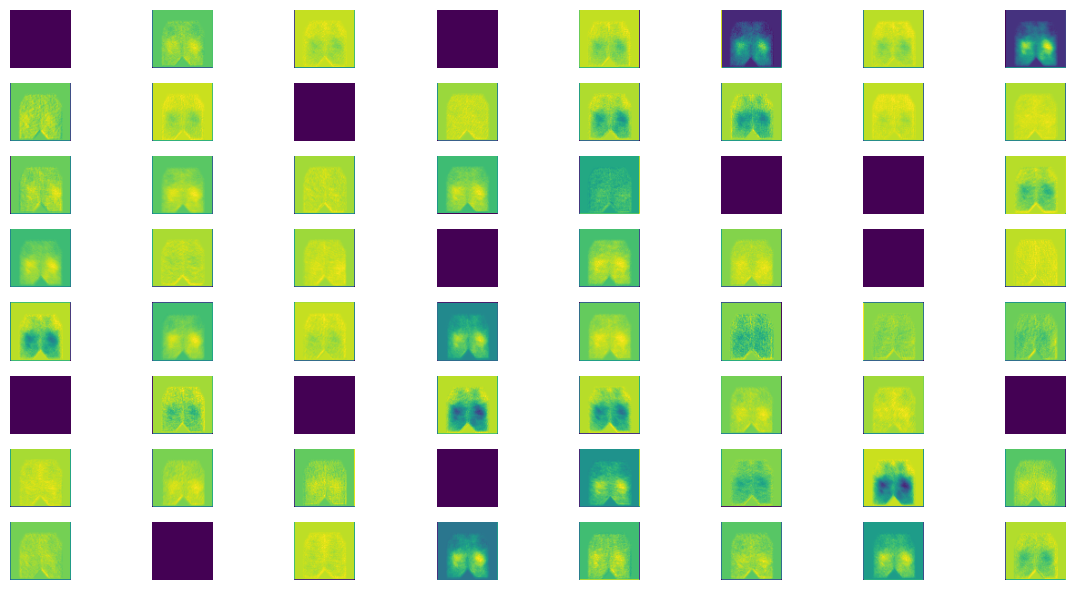

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


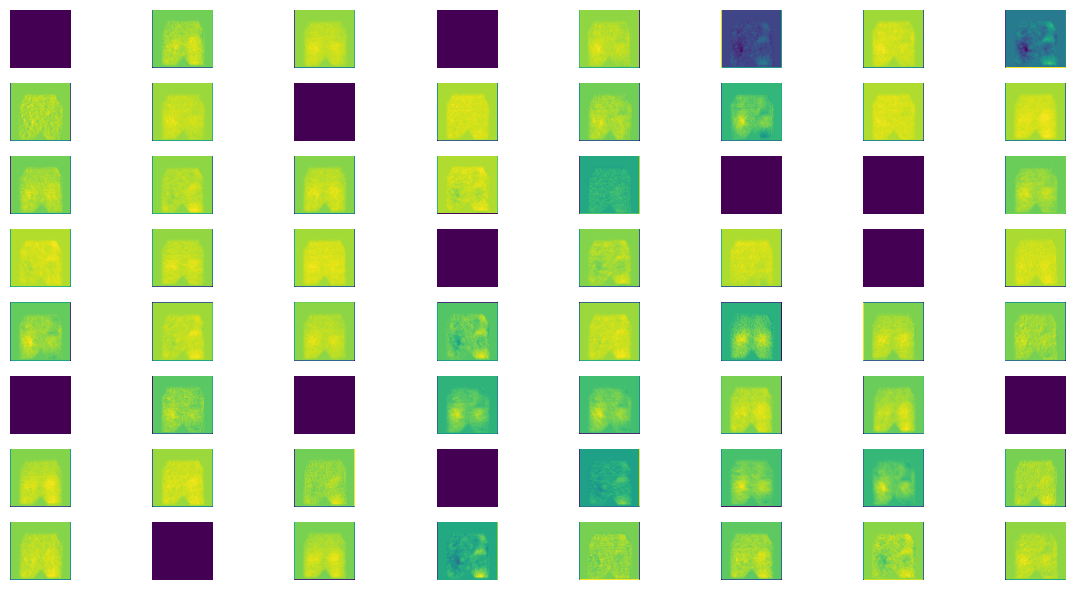

In [8]:
visualize_activation_map(trainX[0], frame_idx=0)
visualize_activation_map(validX[0], frame_idx=0)
visualize_activation_map(testX[0], frame_idx=0)

In [9]:
#import tqdm

pre_activation = []
for f in range(testY.shape[0]):
    sample = testX[f]
    sample_batch = np.expand_dims(sample, axis=0)
    activations = activation_model.predict(sample_batch)  # (1, frames, H, W, filters)
    mean_acti = np.mean(activations[0], axis=0)
    pre_activation.append(mean_acti)

pre_activation = np.array(pre_activation)

print(pre_activation.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
(10, 64, 67, 64)


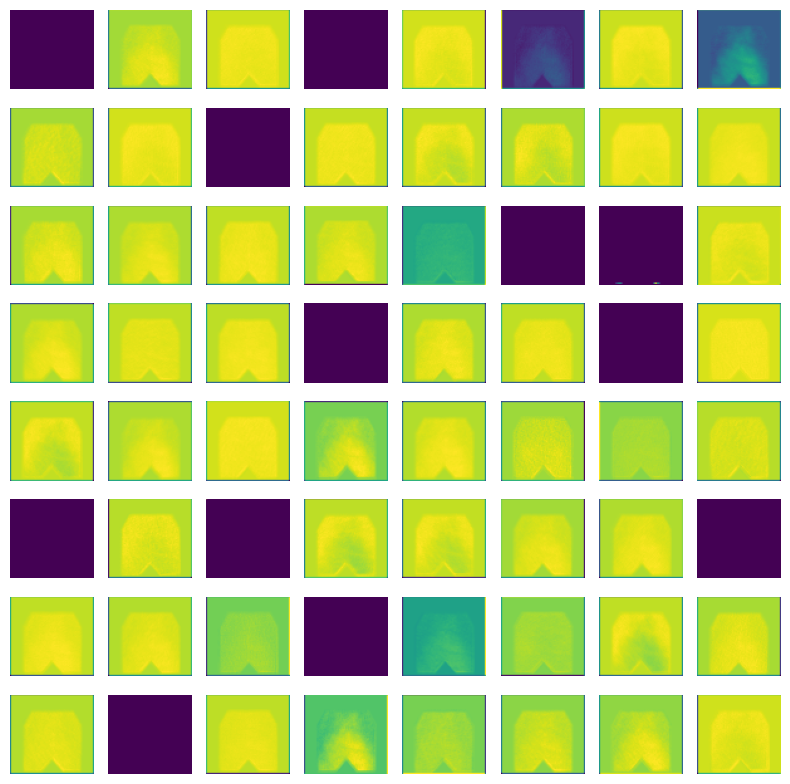

In [10]:
n_filters = pre_activation.shape[3]
n_rows=8
n_cols=8
figsize=(8, 8)
cmap='viridis'



activation = np.mean(pre_activation, axis=0)

# レイアウト計算
if n_cols is None:
    n_cols = int(np.ceil(n_filters / n_rows))

fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
axes = np.array(axes).reshape(-1)

for i in range(n_filters):
    act_map = activation[:, :, i]
    ax = axes[i]
    ax.imshow(act_map, cmap=cmap)
    ax.axis('off')

    # 不要なサブプロットを非表示
for j in range(n_filters, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [11]:
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_activation_map.npy", activation)

In [12]:

# --- 2) ディレクトリごと保存 ---
model.save(f"{rnn_folder}/model_{shap_number}/cnn_model_5epoch.h5")

# --- 3) 後で読み込むとき ---
#from tensorflow.keras.models import load_model
#loaded_model = load_model('saved_models/my_cnn_model')

In [13]:
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_train_features.npy", train_features)
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_valid_features.npy", valid_features)
np.save(f"{rnn_folder}/model_{shap_number}/{date}_{shap_number}_cnn_test_features.npy", test_features)